# Simulated packing rule proof: Fast and Best

This notebook is a deliberately small **proof harness** for the packing contract. It uses synthetic data with known outcomes instead of the masked iHub answers.

It proves two things:

1. **End-to-end pass:** both **Fast** and **Best** solve the same valid order and pass the independent final validator.
2. **Pass/fail rule checks:** each final packing rule gets a legal boundary case and a deliberately invalid case that must return the expected validation error.

Covered rules: physical-item accounting, allowed rotation, buffered carton boundaries, non-overlap, weight, the >6-item 70% fill cap, carton identity, configured usable dimensions, placement-to-carton reference, item-code identity, and non-negative XYZ coordinates.


In [1]:
from copy import deepcopy
from dataclasses import replace
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from bin_packing_3d import solve_order, visualize_result
from bin_packing_3d.models import (
    Box, Item, Orientation, PackedBox, PackingPlan, PhysicalItem, Placement, Position
)
from bin_packing_3d.rules import effective_max_fill_pct, normalize_config, usable_dimensions
from bin_packing_3d.validate import validate_plan


## 1. Shared simulated configuration

The main synthetic carton is **20 × 20 × 20 mm**, but the normal **6 mm height buffer** remains active, leaving only **20 × 20 × 14 mm** usable space.

The pass order contains two physical items. Each weighs 5 kg, so the packed carton sits exactly on its 10 kg limit. This gives us a simple boundary case that both public solver modes must handle correctly.


In [2]:
BOXES = [
    {"Code": "DemoBox", "Length": 20, "Width": 20, "Height": 20, "MaxWeight": 10},
    {"Code": "LargeBox", "Length": 30, "Width": 30, "Height": 30, "MaxWeight": 20},
]

PASS_ORDER = {
    "OrderId": "SIM-PASS",
    "OrderNo": "SIM-PASS",
    "Items": [{
        "Code": "A", "Length": 10, "Width": 10, "Height": 7,
        "Weight": 5, "Quantity": 2, "VerticalRotation": 0,
    }],
}

COMMON = dict(
    high_item_count_threshold=6,
    high_item_count_max_fill_pct=70,
    max_fill_pct=100,
    bin_buffer={"length": 0, "width": 0, "height": 6},
    deterministic=True,
)


## 2. End-to-end pass: Fast and Best

This section uses only the public `solve_order()` API. Both modes receive the exact same order, carton catalogue, and business rules.

The assertions prove that each strategy returns a complete solution and that the shared independent validator accepts it.


In [3]:
mode_results = {}

for mode in ("fast", "best"):
    result = solve_order(
        order=PASS_ORDER,
        boxes=BOXES,
        mode=mode,
        max_runtime_ms=2_000,
        **COMMON,
    )
    assert result.status == "success"
    assert result.validation.valid
    assert result.metrics.packed_item_count == 2
    assert result.metrics.unpacked_item_count == 0
    assert not result.validation.errors
    mode_results[mode] = result

[
    {
        "mode": mode,
        "strategy": result.strategy,
        "cartons": result.metrics.box_count,
        "packed_items": result.metrics.packed_item_count,
        "validation": "PASS",
        "search_status": result.search_status,
        "optimality_proven": result.optimality_proven,
    }
    for mode, result in mode_results.items()
]


[{'mode': 'fast',
  'strategy': 'fast_fit',
  'cartons': 1,
  'packed_items': 2,
  'validation': 'PASS',
  'search_status': 'heuristic',
  'optimality_proven': False},
 {'mode': 'best',
  'strategy': 'best_fit',
  'cartons': 1,
  'packed_items': 2,
  'validation': 'PASS',
  'search_status': 'optimal',
  'optimality_proven': True}]

### Visual proof: Fast and Best packing layouts

The same validated result is rendered for each strategy. The wireframe is the **usable carton space after the 6 mm height buffer**, and the solid cuboids are the placed physical items. These plots are explanatory; the independent validator above remains the authoritative pass/fail check.


FAST — fast_fit — validation PASS


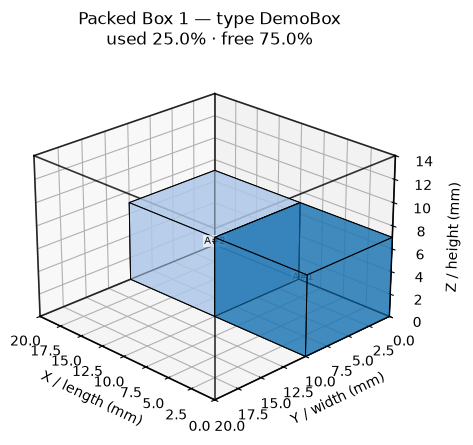

BEST — best_fit — validation PASS


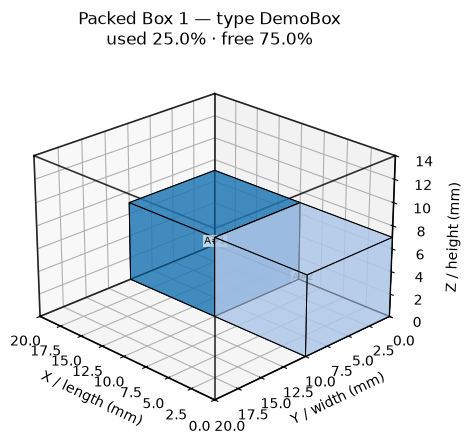

In [4]:
for mode in ("fast", "best"):
    result = mode_results[mode]
    print(f"{mode.upper()} — {result.strategy} — validation PASS")
    visualize_result(result, show=True, elevation=24, azimuth=135)


## 3. Pass/fail harness for every rule

A correct solver normally avoids creating illegal placements, so we should not wait for Fast or Best to make a mistake just to test a guardrail.

Instead, each check below starts from a known-valid packing plan. The **PASS** version must validate. Then one property is deliberately corrupted and the **FAIL** version must be rejected with the exact expected validation code.


In [5]:
def error_codes(result):
    return {error.code for error in result.errors}

def assert_pass(name, plan, items, boxes, config):
    result = validate_plan(plan, items, boxes, config)
    assert result.valid, f"{name}: expected PASS, got {error_codes(result)}"
    return {"rule": name, "case": "PASS", "observed": "valid"}

def assert_fail(name, expected_code, plan, items, boxes, config):
    result = validate_plan(plan, items, boxes, config)
    codes = error_codes(result)
    assert not result.valid, f"{name}: expected FAIL but plan passed"
    assert expected_code in codes, f"{name}: expected {expected_code!r}, got {codes}"
    return {"rule": name, "case": "FAIL", "observed": expected_code}

def make_case(
    item_dimensions=(10, 10, 7), count=2, item_weight=5,
    vertical_rotation=False, box_dimensions=(20, 20, 20),
    max_weight=10, positions=None, config=None,
):
    cfg = normalize_config(config or {
        "bin_buffer": {"length": 0, "width": 0, "height": 6},
        "max_fill_pct": 100,
        "high_item_count_threshold": 6,
        "high_item_count_max_fill_pct": 70,
    })
    source = Item("A", *item_dimensions, item_weight, count, vertical_rotation)
    items = [PhysicalItem(f"A#{i + 1}", source) for i in range(count)]
    box = Box("DemoBox", *box_dimensions, max_weight)
    positions = positions or [Position(i * 10, 0, 0) for i in range(count)]
    placements = [
        Placement(item.instance_id, item.code, "DemoBox-1",
                  Orientation(*item_dimensions), position)
        for item, position in zip(items, positions)
    ]
    plan = PackingPlan([
        PackedBox("DemoBox", "DemoBox-1", usable_dimensions(box, cfg), placements)
    ])
    return plan, items, [box], cfg

proof = []


### 3.1 Physical-item accounting

Every expanded physical item must be accounted for exactly once. The pass plan contains both items. The fail plan silently drops one item and must be rejected as `missing_item`.


In [6]:
plan, items, boxes, cfg = make_case()
proof.append(assert_pass("Item accounting", plan, items, boxes, cfg))
bad = deepcopy(plan)
bad.packed_boxes[0].placements.pop()
proof.append(assert_fail("Item accounting", "missing_item", bad, items, boxes, cfg))


### 3.2 Allowed rotation

With `VerticalRotation = 0`, length and width may swap, but height cannot become a side dimension. The fail case forces a forbidden orientation.


In [7]:
plan, items, boxes, cfg = make_case(count=1, item_weight=1)
proof.append(assert_pass("Allowed rotation", plan, items, boxes, cfg))
bad = deepcopy(plan)
bad.packed_boxes[0].placements[0] = replace(
    bad.packed_boxes[0].placements[0], orientation=Orientation(10, 7, 10)
)
proof.append(assert_fail("Allowed rotation", "orientation", bad, items, boxes, cfg))


### 3.3 Buffered usable boundary

The external carton is 20 mm high, but the 6 mm buffer leaves 14 mm usable. Ending exactly at 14 mm passes; exceeding it by 0.1 mm fails.


In [8]:
plan, items, boxes, cfg = make_case(
    count=1, item_weight=1, positions=[Position(0, 0, 7)]
)
proof.append(assert_pass("Buffered boundary", plan, items, boxes, cfg))
bad = deepcopy(plan)
bad.packed_boxes[0].placements[0] = replace(
    bad.packed_boxes[0].placements[0], position=Position(0, 0, 7.1)
)
proof.append(assert_fail("Buffered boundary", "boundary", bad, items, boxes, cfg))


### 3.4 Non-overlap

Touching cuboids are allowed. Intersecting cuboid interiors are not.


In [9]:
plan, items, boxes, cfg = make_case(
    positions=[Position(0, 0, 0), Position(10, 0, 0)]
)
proof.append(assert_pass("Non-overlap", plan, items, boxes, cfg))
bad = deepcopy(plan)
bad.packed_boxes[0].placements[1] = replace(
    bad.packed_boxes[0].placements[1], position=Position(9.9, 0, 0)
)
proof.append(assert_fail("Non-overlap", "overlap", bad, items, boxes, cfg))


### 3.5 Weight limit

Exactly 10 kg in a 10 kg carton passes. Increasing each item from 5 kg to 5.01 kg makes the carton overweight and must fail.


In [10]:
plan, items, boxes, cfg = make_case(item_weight=5)
proof.append(assert_pass("Weight limit", plan, items, boxes, cfg))
bad_plan, bad_items, bad_boxes, bad_cfg = make_case(item_weight=5.01)
proof.append(assert_fail(
    "Weight limit", "weight", bad_plan, bad_items, bad_boxes, bad_cfg
))


### 3.6 High-item-count fill cap

The stricter **70%** fill rule applies when expanded physical item count is **greater than 6**.

A 10 × 10 × 10 mm usable carton has 1,000 mm³. Seven 10 × 10 × 1 mm items occupy exactly 700 mm³ and pass. Eight occupy 800 mm³ and the deliberately forced one-carton plan fails.


In [11]:
fill_cfg = {
    "bin_buffer": {"length": 0, "width": 0, "height": 0},
    "max_fill_pct": 100,
    "high_item_count_threshold": 6,
    "high_item_count_max_fill_pct": 70,
}

plan, items, boxes, cfg = make_case(
    item_dimensions=(10, 10, 1), count=7, item_weight=0.1,
    box_dimensions=(10, 10, 10), max_weight=10,
    positions=[Position(0, 0, z) for z in range(7)], config=fill_cfg,
)
assert effective_max_fill_pct(len(items), cfg) == 70
proof.append(assert_pass("70% high-item fill cap", plan, items, boxes, cfg))

bad_plan, bad_items, bad_boxes, bad_cfg = make_case(
    item_dimensions=(10, 10, 1), count=8, item_weight=0.1,
    box_dimensions=(10, 10, 10), max_weight=10,
    positions=[Position(0, 0, z) for z in range(8)], config=fill_cfg,
)
assert effective_max_fill_pct(len(bad_items), bad_cfg) == 70
proof.append(assert_fail(
    "70% high-item fill cap", "fill_cap",
    bad_plan, bad_items, bad_boxes, bad_cfg
))


### 3.7 Carton identity and configured usable dimensions

A plan cannot invent a carton type. It also cannot pretend the usable dimensions are the external dimensions and thereby bypass the configured buffer.


In [12]:
plan, items, boxes, cfg = make_case(count=1, item_weight=1)
proof.append(assert_pass("Carton identity", plan, items, boxes, cfg))

bad = deepcopy(plan)
bad.packed_boxes[0].box_code = "NotInCatalogue"
proof.append(assert_fail("Carton identity", "unknown_box", bad, items, boxes, cfg))

bad = deepcopy(plan)
bad.packed_boxes[0].usable_dimensions = Orientation(20, 20, 20)
proof.append(assert_fail(
    "Configured usable dimensions", "usable_dimensions", bad, items, boxes, cfg
))


### 3.8 Placement reference, item identity, and XYZ origin

The validator also rejects a placement that points at the wrong carton instance, changes the item code, or starts outside the carton with a negative coordinate.


In [13]:
plan, items, boxes, cfg = make_case(count=1, item_weight=1)
proof.append(assert_pass("Placement references", plan, items, boxes, cfg))

bad = deepcopy(plan)
bad.packed_boxes[0].placements[0] = replace(
    bad.packed_boxes[0].placements[0], box_instance_id="WrongBox-1"
)
proof.append(assert_fail(
    "Placement references", "box_reference", bad, items, boxes, cfg
))

bad = deepcopy(plan)
bad.packed_boxes[0].placements[0] = replace(
    bad.packed_boxes[0].placements[0], item_code="WRONG"
)
proof.append(assert_fail("Item identity", "item_code", bad, items, boxes, cfg))

bad = deepcopy(plan)
bad.packed_boxes[0].placements[0] = replace(
    bad.packed_boxes[0].placements[0], position=Position(-0.1, 0, 0)
)
proof.append(assert_fail(
    "Non-negative XYZ", "negative_coordinate", bad, items, boxes, cfg
))


## 4. Proof summary

Every row below is backed by an assertion. If a future change weakens a rule, the relevant cell fails rather than merely changing a chart or printed message.


In [14]:
proof


[{'rule': 'Item accounting', 'case': 'PASS', 'observed': 'valid'},
 {'rule': 'Item accounting', 'case': 'FAIL', 'observed': 'missing_item'},
 {'rule': 'Allowed rotation', 'case': 'PASS', 'observed': 'valid'},
 {'rule': 'Allowed rotation', 'case': 'FAIL', 'observed': 'orientation'},
 {'rule': 'Buffered boundary', 'case': 'PASS', 'observed': 'valid'},
 {'rule': 'Buffered boundary', 'case': 'FAIL', 'observed': 'boundary'},
 {'rule': 'Non-overlap', 'case': 'PASS', 'observed': 'valid'},
 {'rule': 'Non-overlap', 'case': 'FAIL', 'observed': 'overlap'},
 {'rule': 'Weight limit', 'case': 'PASS', 'observed': 'valid'},
 {'rule': 'Weight limit', 'case': 'FAIL', 'observed': 'weight'},
 {'rule': '70% high-item fill cap', 'case': 'PASS', 'observed': 'valid'},
 {'rule': '70% high-item fill cap', 'case': 'FAIL', 'observed': 'fill_cap'},
 {'rule': 'Carton identity', 'case': 'PASS', 'observed': 'valid'},
 {'rule': 'Carton identity', 'case': 'FAIL', 'observed': 'unknown_box'},
 {'rule': 'Configured usable

In [15]:
assert all(result.validation.valid for result in mode_results.values())
assert len(proof) == 19
assert sum(row["case"] == "PASS" for row in proof) == 8
assert sum(row["case"] == "FAIL" for row in proof) == 11

print("PROOF COMPLETE")
print("Fast: PASS")
print("Best: PASS")
print("Rule checks: 19/19 behaved as expected")


PROOF COMPLETE
Fast: PASS
Best: PASS
Rule checks: 19/19 behaved as expected


## Conclusion

The simulated evidence separates **packing strategy** from **rule enforcement**.

Fast and Best both use the same public API and must pass the same independent validator. Legal boundary cases are accepted, while deliberate violations are rejected. The 6 mm clearance, 70% high-item-count fill policy, weight limit, rotation rule, geometry, item accounting, and carton identity are therefore executable constraints rather than documentation-only assumptions.
